In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# !pip install kagglehub[pandas-datasets]
import kagglehub
from astropy.table import Table
from scipy.optimize import curve_fit
import random

__Plotting an Astronomical Image__

In [2]:
data = np.loadtxt("astro_image.csv")

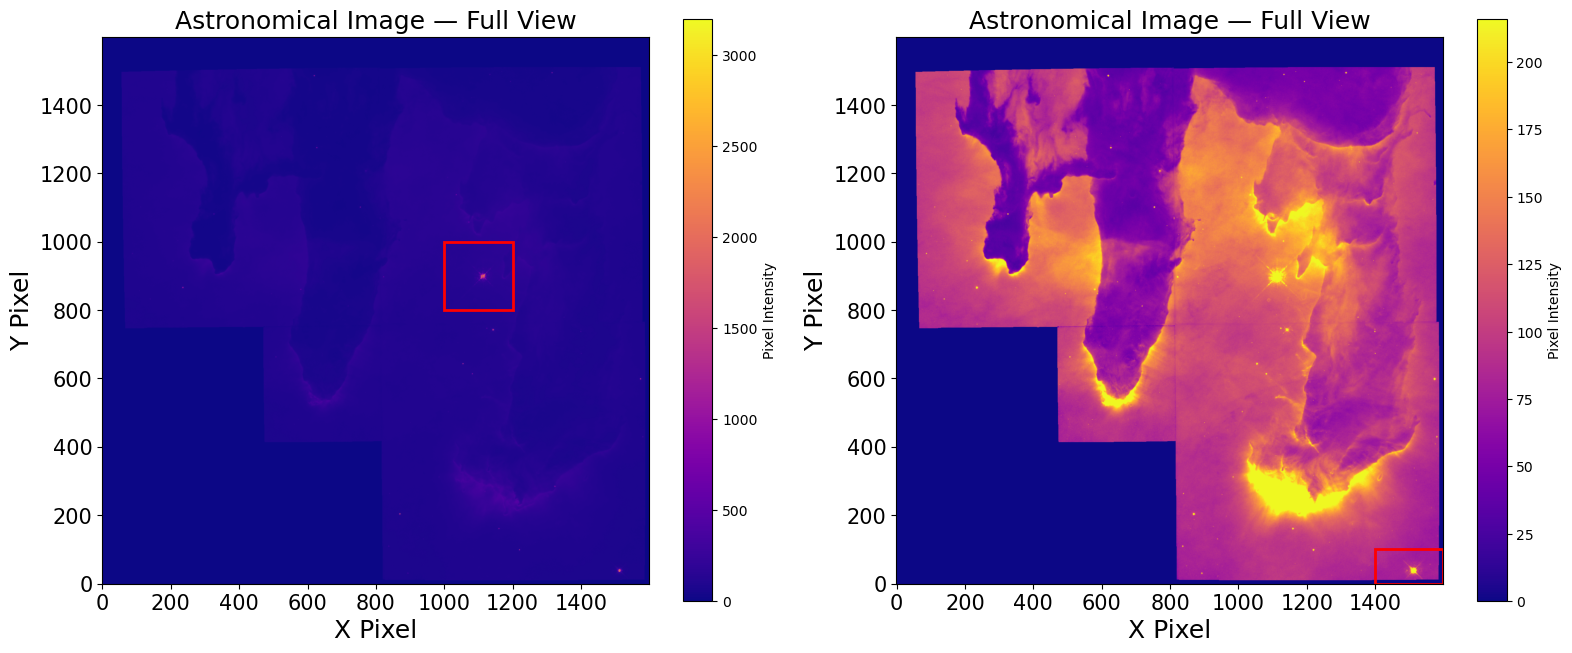

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 10))

img = ax[0].imshow(data, cmap="plasma", origin="lower")
ax[0].set_title("Astronomical Image — Full View", fontsize=18)
ax[0].set_xlabel("X Pixel", fontsize=18)
ax[0].set_ylabel("Y Pixel", fontsize=18)
ax[0].tick_params(labelsize=15)

x1, x2 = 1000, 1200
y1, y2 = 800, 1000
rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                     edgecolor='red', facecolor='none', lw=2)
ax[0].add_patch(rect)
fig.colorbar(img, shrink=0.6, label="Pixel Intensity")

vmin, vmax = np.percentile(data, [1, 99])
img = ax[1].imshow(data, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
ax[1].set_title("Astronomical Image — Full View", fontsize=18)
ax[1].set_xlabel("X Pixel", fontsize=18)
ax[1].set_ylabel("Y Pixel", fontsize=18)
ax[1].tick_params(labelsize=15)

x1b, x2b = 1400, 1600
y1b, y2b = 0, 100
rect = plt.Rectangle((x1b, y1b), x2b - x1b, y2b - y1b,
                     edgecolor='red', facecolor='none', lw=2)
ax[1].add_patch(rect)
fig.colorbar(img, shrink=0.6, label="Pixel Intensity")

plt.tight_layout()
plt.show()

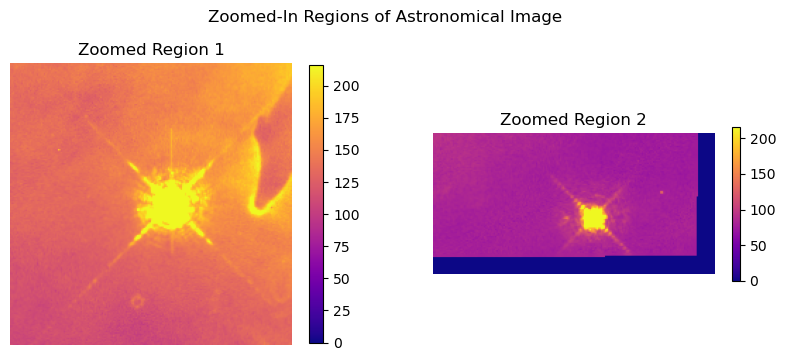

In [4]:
zoom1 = data[y1:y2, x1:x2]
zoom2 = data[y1b:y2b, x1b:x2b]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im1 = axes[0].imshow(zoom1, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Zoomed Region 1")
axes[0].axis('off')
fig.colorbar(im1, shrink=0.9)

im2 = axes[1].imshow(zoom2, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("Zoomed Region 2")
axes[1].axis('off')
fig.colorbar(im2, shrink=0.5)

plt.suptitle("Zoomed-In Regions of Astronomical Image")
plt.show()

__Pandas and Ramen__

In [5]:
# Download latest version
# path = kagglehub.dataset_download("residentmario/ramen-ratings")

# print("Path to dataset files:", path)

In [6]:
df_ramen = pd.read_csv('ramen-ratings.csv')

1. What are the column names in this dataset?

In [7]:
print(f'The column names in the dataset are:\n{df_ramen.columns.to_list()}')

The column names in the dataset are:
['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']


2. What is the ramen style of the 27th entry?

In [8]:
ramen_style_27 = df_ramen['Style'].iloc[26]

print(f'The ramen style of the 27th entry is: {ramen_style_27}')

The ramen style of the 27th entry is: Pack


3. How many different ramen brands are there?

In [9]:
brands = len(df_ramen['Brand'].unique())
print(f'There are {brands} different ramen brands in the dataset.')

There are 355 different ramen brands in the dataset.


4. Sort the dataset by brand names.

In [10]:
df_sorted = df_ramen.sort_values(by='Brand')
print(df_sorted.head(10))

      Review #             Brand  \
229       2351    1 To 3 Noodles   
456       2124          7 Select   
463       2117          7 Select   
877       1703   7 Select/Nissin   
911       1669             A-One   
947       1633             A-One   
1016      1564             A-One   
1289      1291             A-One   
1252      1328  A-Sha Dry Noodle   
424       2156  A-Sha Dry Noodle   

                                                Variety Style   Country Stars  \
229                                      Chatpat Masala  Pack     India     4   
456   Nissin Instant Noodles Tom Yum Seafood Creamy ...  Bowl  Thailand   3.5   
463   Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...  Bowl  Thailand     4   
877                                Super Tom Yum Shrimp   Cup  Thailand   3.5   
911     Mi Ly Instant Noodles Mi Chay Vegetarian Flavor   Cup   Vietnam  1.25   
947             Mi Ly Instant Noodles Mi Bo Beef Flavor   Cup   Vietnam   3.5   
1016      Mì Ly Instant Noodles Mì T

5. How many ramen brands are made in the USA?

In [11]:
usa_unique_brands = len(df_ramen.loc[df_ramen['Country'] == 'USA', 'Brand'].unique())
print(f'There are {usa_unique_brands} unique ramen brands made in the USA')

There are 49 unique ramen brands made in the USA


6. How many ramen brands in the USA make pack-style ramen?

In [12]:
usa_pack_style = len(df_ramen.loc[(df_ramen['Country'] == 'USA') &
                     (df_ramen['Style'] == 'Pack'), 'Brand'].unique())
print(f'There are {usa_pack_style} unique ramen brands in the USA that make pack-style ramen')

There are 27 unique ramen brands in the USA that make pack-style ramen


7. Challenge: Which ramen brands have been in the top ten? (Top tem column entry is not NaN)

In [13]:
been_in_top_ten = df_ramen.loc[df_ramen['Top Ten'].notna(), 'Brand'].unique()
print(f'The following ramen brands have been in the top ten:\n {been_in_top_ten}')

The following ramen brands have been in the top ten:
 ['MAMA' 'Prima Taste' 'Prima' 'Tseng Noodles' 'Wugudaochang'
 'A-Sha Dry Noodle' 'MyKuali' 'CarJEN' 'Maruchan' 'Mamee' 'Mama'
 'Sapporo Ichiban' 'Nongshim' 'Samyang Foods' 'Paldo' 'Indomie' 'Koka'
 'Mi Sedaap' 'Nissin' 'Myojo' 'Doll']


__Linear Regression__

In [14]:
data = Table.read('global_CCl4_MM.dat', format='ascii')

df = data.to_pandas()

df = df.iloc[:, [0, 1, 6, 7]]

df.columns = ['year', 'month', 'global mean concentration', 'global mean concentration sd']

# Make date column since there is only year and month column
df['date'] = df['year'] + (df['month'] - 1)/12

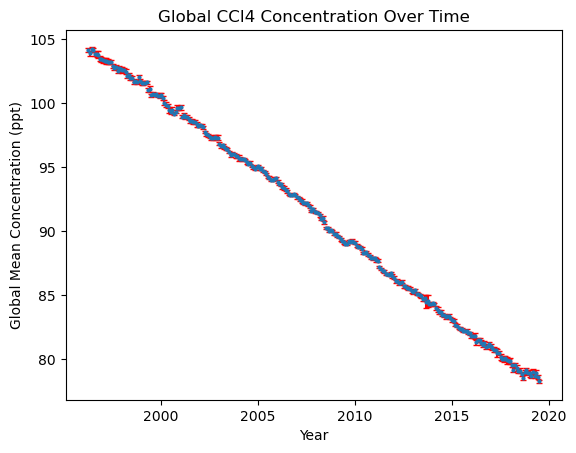

In [15]:
x = df['date']
y = df['global mean concentration']
err = df['global mean concentration sd']

plt.figure()
plt.errorbar(x, y, yerr=err, fmt='o', ecolor='red', capsize=2, markersize=2)
plt.xlabel('Year')
plt.ylabel('Global Mean Concentration (ppt)')
plt.title('Global CCl4 Concentration Over Time')
plt.show()

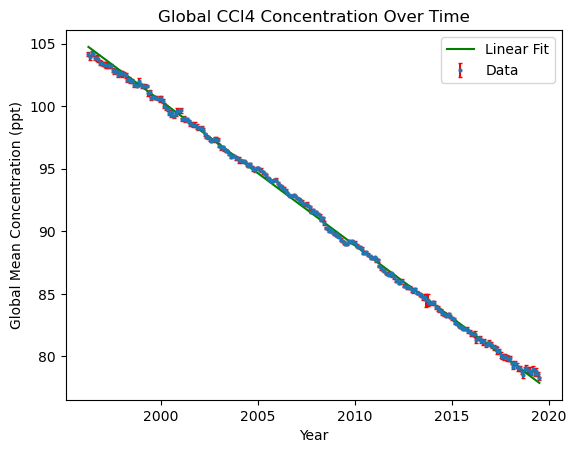

In [16]:
df_clean = df.dropna(subset=['global mean concentration', 'global mean concentration sd'])
x = df_clean['date']
# Shift x so that first year is zero (helps with evaluating fit since numbers are large)
x0 = x.values[0]
x_shifted = x - x0
y = df_clean['global mean concentration']
err = df_clean['global mean concentration sd']

def linear_fit(x, m, b):
    return m*x + b

popt, pcov = curve_fit(linear_fit, x_shifted, y, sigma=err)
m_fit, b_fit = popt

plt.figure()
plt.errorbar(x, y, yerr=err, fmt='o', ecolor='red', capsize=1.5, markersize=2, label='Data')
plt.plot(x, linear_fit(x_shifted, *popt), color='green', label='Linear Fit')
plt.xlabel('Year')
plt.ylabel('Global Mean Concentration (ppt)')
plt.title('Global CCl4 Concentration Over Time')
plt.legend()
plt.show()

In [17]:
# Example of without shift
popt, pcov = curve_fit(linear_fit, x, y, sigma=err)
m_fit_no_shift, b_fit_no_shift = popt

y_fit = linear_fit(x, *popt)
chi2 = np.sum(((y - y_fit) / err)**2)
reduced_chi2 = chi2 / (len(y) - len(popt))
print(f'Fit parameters: m = {m_fit_no_shift:.3f}, b = {b_fit_no_shift:.3f}')
print(f'Reduced chi-square:{reduced_chi2:.3f}')

popt, pcov = curve_fit(linear_fit, x_shifted, y, sigma=err)
m_fit, b_fit = popt

y_fit = linear_fit(x_shifted, *popt)
chi2 = np.sum(((y - y_fit) / err)**2)
reduced_chi2 = chi2 / (len(y) - len(popt))
print(f'\nFit parameters: m = {m_fit:.3f}, b = {b_fit:.3f}')
print(f'Reduced chi-square: {reduced_chi2:.3f}')

Fit parameters: m = -1.154, b = 2409.219
Reduced chi-square:4.437

Fit parameters: m = -1.154, b = 104.729
Reduced chi-square: 4.437


When we do not shift the x-axis, we get:
- slope m = -1.154
- y-intercept b = 2409.219
- Reduced chi-squared:  4.437

When we do shift the x-axis, we get:
- slope m = -1.154
- y-intercept b = 104.219
- Reduced chi-squared:  4.437

The reason for the discrepancy between the b values is due to the x axis having large numbers compared to the rest of the data, which throws off the b value. Based on the reduced chi-squared, we have a pretty good fit since it is close to 1.

__Optional OOP, for Extra Credit__

In [18]:
class PlayingCharacter:
    def __init__(self, name, race, char_class, age):
        """Initialize a character with basic properties."""
        self.name = name   
        self.race = race 
        self.char_class = char_class
        self.age = age 
        self.level = 1
        self.stats = None 

    def roll_stats(self, sort_order=None):
        """
        Roll 6 random numbers (3-18) for stats and assign to character.
        sort_order = 'high_to_low' or 'low_to_high'
        """
        # Roll 6 random numbers for stats
        rolls = [random.randint(3, 18) for _ in range(6)]

        # Stat names
        keys = ['Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma']

        # Sort rolls if requested
        if sort_order == 'high_to_low':
            rolls.sort(reverse=True)
        elif sort_order == 'low_to_high':
            rolls.sort()

        # Assign each roll to a stat
        self.stats = {key: roll for key, roll in zip(keys, rolls)}

    def level_up(self):
        """Increases the character's level by 1."""
        self.level += 1
        print(f"{self.name} has leveled up! New level: {self.level}")

In [20]:
my_character = PlayingCharacter(name="Oblivion", race="Dragonborn", char_class="Warrior", age=30)

print("Character Info:")
print(f"Name: {my_character.name}")
print(f"Race: {my_character.race}")
print(f"Class: {my_character.char_class}")
print(f"Age: {my_character.age}")
print(f"Level: {my_character.level}")
print(f"Stats before rolling: {my_character.stats}")

my_character.roll_stats(sort_order='high_to_low')

print("\nStats after rolling:")
for stat, value in my_character.stats.items():
    print(f"{stat}: {value}")

my_character.level_up()

Character Info:
Name: Oblivion
Race: Dragonborn
Class: Warrior
Age: 30
Level: 1
Stats before rolling: None

Stats after rolling:
Strength: 16
Dexterity: 16
Constitution: 12
Intelligence: 10
Wisdom: 8
Charisma: 6
Oblivion has leveled up! New level: 2
